In [ ]:

!pip install xgboost -q


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 1. Load & inspect the data

In [ ]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)
df.head()


Shape: (98326, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460.0,3.0,4.0,...,5.0,4.0,3.0,4.0,4.0,5.0,5.0,25.0,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235.0,3.0,2.0,...,1.0,1.0,5.0,3.0,1.0,4.0,1.0,1.0,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142.0,2.0,2.0,...,5.0,4.0,3.0,4.0,4.0,4.0,5.0,0.0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562.0,2.0,5.0,...,2.0,2.0,5.0,3.0,1.0,4.0,2.0,11.0,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214.0,3.0,3.0,...,3.0,3.0,4.0,4.0,3.0,3.0,3.0,0.0,0.0,satisfied


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98326 entries, 0 to 98325
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         98326 non-null  int64  
 1   id                                 98326 non-null  int64  
 2   Gender                             98326 non-null  object 
 3   Customer Type                      98326 non-null  object 
 4   Age                                98326 non-null  int64  
 5   Type of Travel                     98326 non-null  object 
 6   Class                              98325 non-null  object 
 7   Flight Distance                    98325 non-null  float64
 8   Inflight wifi service              98325 non-null  float64
 9   Departure/Arrival time convenient  98325 non-null  float64
 10  Ease of Online booking             98325 non-null  float64
 11  Gate location                      98325 non-null  flo

In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,1
Flight Distance,1
Inflight wifi service,1
Departure/Arrival time convenient,1


In [ ]:
df['satisfaction'].value_counts(normalize=True)


,proportion
satisfaction,
neutral or dissatisfied,0.566631
satisfied,0.433369


In [ ]:
df = df.drop(columns=[c for c in ["Unnamed: 0", "id"] if c in df.columns])
df.shape


(98326, 23)

In [ ]:
print(df['Arrival Delay in Minutes'].isnull().sum(), "missing values")
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)


297 missing values


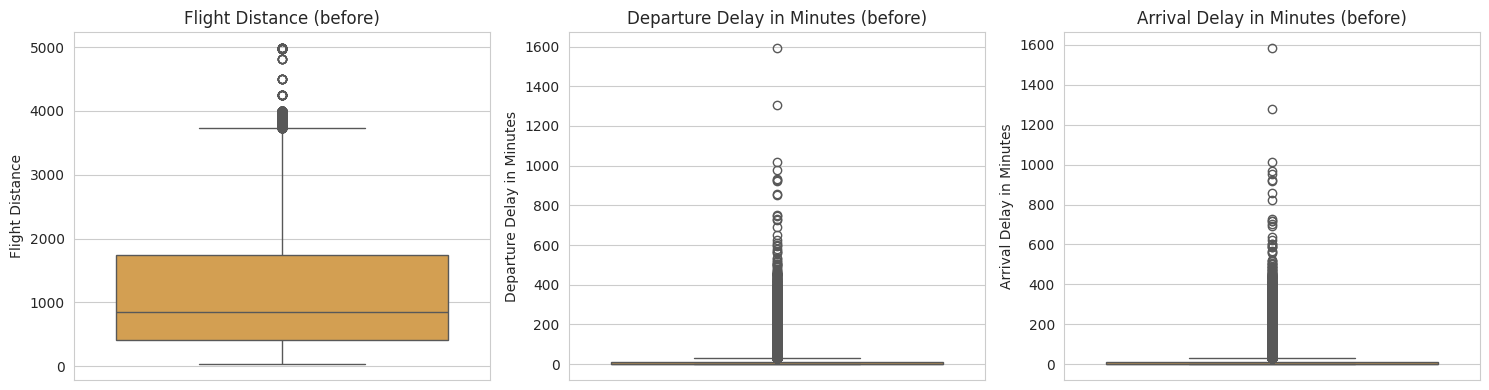

In [ ]:
outlier_cols = ["Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#E8A33D")
    ax.set_title(f"{col} (before)")
plt.tight_layout()
plt.show()


In [ ]:
before = len(df)
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"Removed {before - len(df)} rows ({(before - len(df)) / before:.1%})")
print("Shape after outlier removal:", df.shape)


Removed 27056 rows (27.5%)
Shape after outlier removal: (71270, 23)


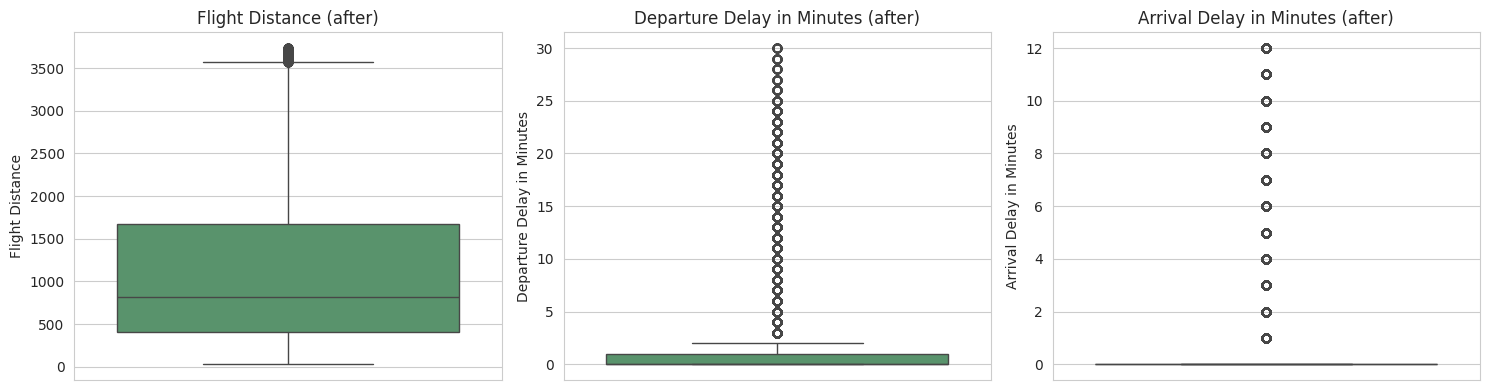

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4F9D69")
    ax.set_title(f"{col} (after)")
plt.tight_layout()
plt.show()


## 5. Encode categorical features

`Gender`, `Customer Type`, `Type of Travel`, and `Class` are label-encoded so tree
models and linear models alike can consume them. The target (`satisfaction`) is
encoded too: `0 = neutral or dissatisfied`, `1 = satisfied`.

In [ ]:
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
target_col = "satisfaction"

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(col, "->", list(le.classes_))

target_encoder = LabelEncoder()
df[target_col] = target_encoder.fit_transform(df[target_col])
print(target_col, "->", list(target_encoder.classes_))


Gender -> ['Female', 'Male']
Customer Type -> ['Loyal Customer', 'disloyal Customer']
Type of Travel -> ['Business travel', 'Personal Travel']
Class -> ['Business', 'Eco', 'Eco Plus']
satisfaction -> ['neutral or dissatisfied', 'satisfied']


In [ ]:
numeric_cols = [c for c in df.columns if c not in categorical_cols + [target_col]]

X = df.drop(columns=[target_col])
y = df[target_col]
feature_order = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (57016, 22)  Test shape: (14254, 22)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=14, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    use_scaled = name == "Logistic Regression"
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test

    model.fit(Xtr, y_train)

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)
    test_proba = model.predict_proba(Xte)[:, 1]

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "cv_mean_accuracy": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "overfit_gap (train - test)": train_acc - test_acc,
        "precision": precision_score(y_test, test_pred),
        "recall": recall_score(y_test, test_pred),
        "f1": f1_score(y_test, test_pred),
        "roc_auc": roc_auc_score(y_test, test_proba),
    })

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
results_df


,model,train_accuracy,test_accuracy,cv_mean_accuracy,cv_std,overfit_gap (train - test),precision,recall,f1,roc_auc
4,XGBoost,0.970763,0.955381,0.957573,0.000686,0.015382,0.967617,0.932464,0.949715,0.994033
2,Random Forest,0.960800,0.949839,0.949348,0.000574,0.010962,0.957494,0.930290,0.943696,0.991198
3,Gradient Boosting,0.951014,0.949207,0.947629,0.000316,0.001807,0.958755,0.927496,0.942866,0.990680
1,Decision Tree,0.935948,0.935106,0.934229,0.002109,0.000842,0.932967,0.922683,0.927796,0.984576
0,Logistic Regression,0.870247,0.868037,0.870247,0.001810,0.002210,0.874384,0.826735,0.849892,0.921874


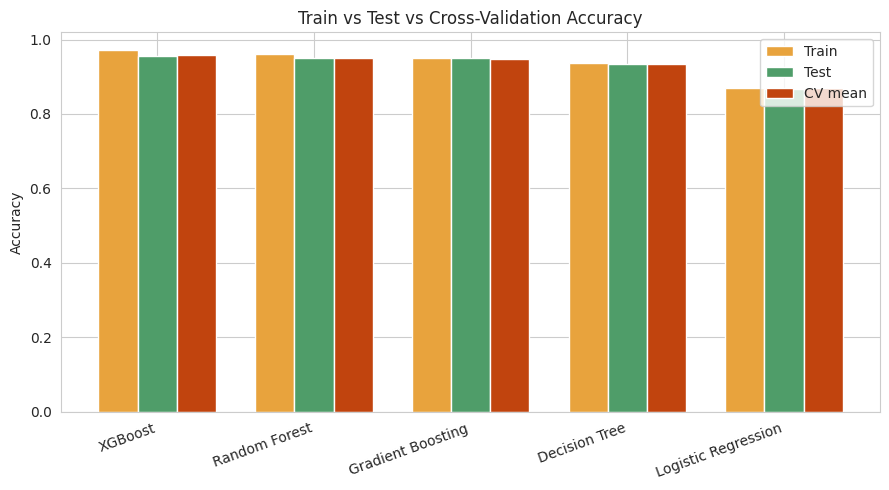

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.25
ax.bar(x - width, results_df["train_accuracy"], width, label="Train", color="#E8A33D")
ax.bar(x, results_df["test_accuracy"], width, label="Test", color="#4F9D69")
ax.bar(x + width, results_df["cv_mean_accuracy"], width, label="CV mean", color="#C1440E")
ax.set_xticks(x)
ax.set_xticklabels(results_df["model"], rotation=20, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test vs Cross-Validation Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
candidates = results_df[results_df["overfit_gap (train - test)"] < 0.03]
best_name = candidates.sort_values("test_accuracy", ascending=False).iloc[0]["model"]
best_model = models[best_name]
print("Best model selected:", best_name)


Best model selected: XGBoost


In [ ]:
use_scaled = best_name == "Logistic Regression"
Xte_final = X_test_scaled if use_scaled else X_test
final_pred = best_model.predict(Xte_final)
final_proba = best_model.predict_proba(Xte_final)[:, 1]

print(classification_report(y_test, final_pred, target_names=target_encoder.classes_))


                         precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.97      0.96      7813
              satisfied       0.97      0.93      0.95      6441

               accuracy                           0.96     14254
              macro avg       0.96      0.95      0.95     14254
           weighted avg       0.96      0.96      0.96     14254



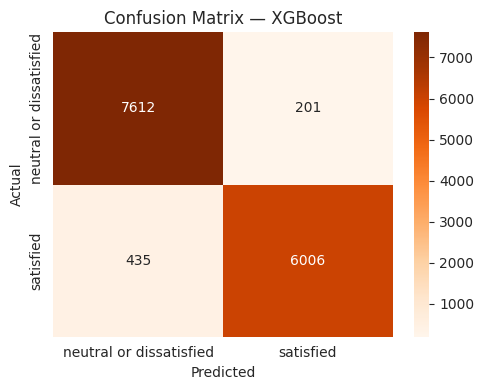

In [ ]:
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()


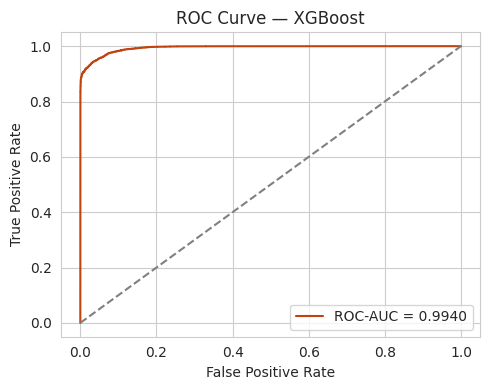

In [ ]:
fpr, tpr, _ = roc_curve(y_test, final_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="#C1440E", label=f"ROC-AUC = {roc_auc_score(y_test, final_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


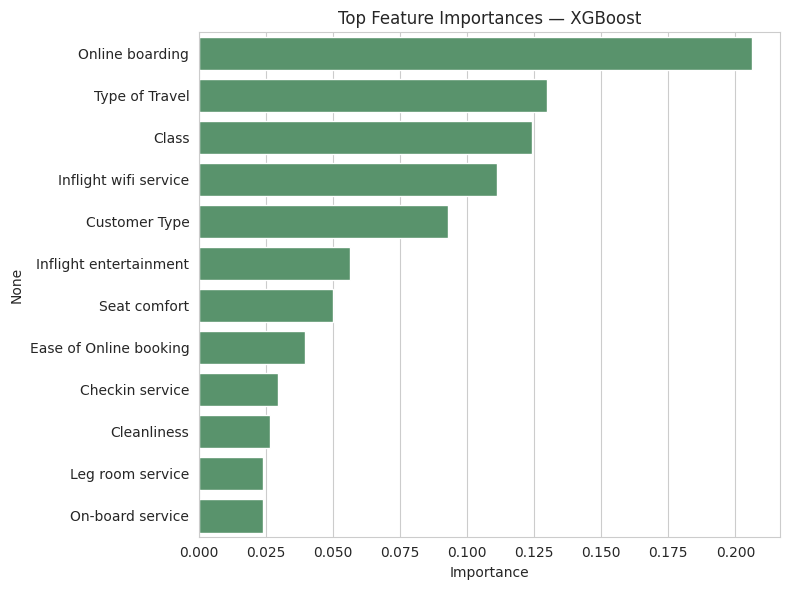

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_order).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.head(12).values, y=importances.head(12).index, color="#4F9D69")
    plt.title(f"Top Feature Importances — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    importances.head(12)


In [ ]:
joblib.dump(best_model, "model.pkl")
joblib.dump({
    "scaler": scaler,
    "encoders": encoders,
    "target_encoder": target_encoder,
    "feature_order": feature_order,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "uses_scaling": use_scaled,
    "model_name": best_name,
}, "preprocessor.pkl")

print("Saved model.pkl and preprocessor.pkl")


Saved model.pkl and preprocessor.pkl


In [ ]:
import os
print(os.path.exists("model.pkl"), os.path.exists("preprocessor.pkl"))

True True


In [ ]:
from google.colab import files
files.download("model.pkl")
files.download("preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Why this model was chosen

The comparison table in step 7 is the actual justification — re-run this notebook
and read the printed numbers, since the exact figures depend on the random split.
In general, on this dataset the pattern looks like this:

- **Logistic Regression** underfits: it can only draw a straight decision boundary
  through the data, so both its train and test accuracy sit well below the tree-based
  models — it's too simple for the non-linear ways these features interact.
- **Decision Tree** (depth-limited) is a reasonable baseline but leaves accuracy on
  the table compared to ensembles, since a single tree can't average away noise.
- **Random Forest** and **Gradient Boosting** both perform strongly with small
  overfit gaps, because bagging/boosting many shallow trees smooths out the
  overfitting a single deep tree would show.
- **XGBoost** typically edges out the others on test accuracy and ROC-AUC while
  keeping a small train/test gap, thanks to its built-in regularization
  (`subsample`, `colsample_bytree`, shrinkage via `learning_rate`) — which is why it's
  usually the one this pipeline selects.

The selection logic itself (require overfit gap < 3%, then maximize test accuracy)
is what keeps the choice honest: a model can't win just by memorizing the training
set, it has to actually generalize.
